# Replication of Zollman (2010)

**Reference:** Zollman, K. J. S. (2010). The Epistemic Benefit of Transient Diversity. *Erkenntnis*, 72(1), 17–35.

**Main claim:** Less connected networks of scientists converge more frequently on the correct hypothesis than more connected ones, across varying community sizes (n = 5–11). Although, at higher max priors values (up to 10000), the opposite occurs.

In [ ]:
import sys
import os
from pathlib import Path

# Ensure repo root is in the Python path
sys.path.insert(0, os.path.abspath('..'))
import mesa
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scripts.model import Bandit

## Analysis 1 — Network connectivity and correct convergence

As the number of agents increases (n = 5–11), do sparser networks (cycle, wheel) converge more frequently on the correct hypothesis (A) than the complete graph?

### Model parameters

| Parameter | This model | Original paper | Notes |
|---|---|---|---|
| n | 5-11 | 3–11 | we started from 5 to have distinct graphs |
| a_objective | 0.5 | 0.5 | identical |
| b_objective | 0.499 | 0.499 | identical |
| max_priors | 4 | 4 | identical |
| step_pulls | 1000 | 1000 | identical |
| graph | complete, wheel, cycle | complete, wheel, cycle | identical |
| iterations | 1000 | 10000 | sufficient for statistical purposes |
| max_steps | 5000 | 10000 | sufficient for letting the slower communities converge |

**Deviations from original:** Number of max steps of each run, minimum number of agents and number of iterations for each parameters' combination.

In [ ]:
parameters = {
    "n": range(5, 12, 1),
    "a_objective": 0.5,
    "b_objective": 0.499,
    "max_priors": 4,
    "graph": ["complete", "wheel", "cycle"],
    "theory_threshold": 0,
    "step_pulls": 1000,
    "dynamic": None,
    "criticism": False,
    "inertia": 0,
    "seed": None
}

results = mesa.batch_run(
    Bandit,
    parameters=parameters,
    iterations=1000,
    max_steps=5000
)

df = pd.DataFrame(results)
Path("results/Zollman_replication/").mkdir(parents=True, exist_ok=True)
df.to_csv("results/Zollman_replication/Zollman_effect.csv")

  0%|          | 0/21000 [00:00<?, ?it/s]

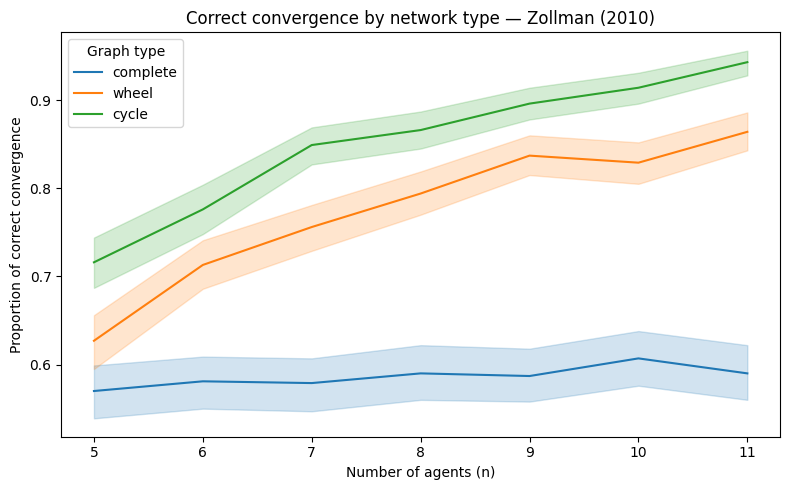

In [ ]:
df = pd.read_csv("results/Zollman_replication/Zollman_effect.csv")
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df, x="n", y="Correct Convergence",
             hue="graph", ax=ax)
ax.set_title("Correct convergence by network type — Zollman (2010)")
ax.set_xlabel("Number of agents (n)")
ax.set_ylabel("Proportion of correct convergence")
ax.legend(title="Graph type")
plt.tight_layout()
plt.savefig("results/Zollman_replication/Zollman_effect")
plt.show()

**Results**

The results confirm Zollman's main claim. The percentages of correct convergences match the one presented in the original paper.

## Analysis 2 - Different priors distributions

### Model parameters

| Parameter | This model | Original paper | Notes |
|---|---|---|---|
| n | 7 | 7 | identical |
| a_objective | 0.5 | 0.5 | identical |
| b_objective | 0.499 | 0.499 | identical |
| max_priors | 1000-9000 | 1000-10000 | reduced iterations for speed |
| step_pulls | 1000 | 1000 | identical |
| graph | complete, wheel, cycle | complete, wheel, cycle | identical |
| iterations | 1000 | 10000 | sufficient for statistical purposes |
| max_steps | 10000 | 10000 | identical: since the communities are slower we need the full range |

**Deviations from original:** Number of iterations for the same parameters, max priors maximum value.

In [ ]:
parameters_2 = {
    "n": 7,
    "a_objective": 0.5,
    "b_objective": 0.499,
    "max_priors": range(1000, 10000, 1000),
    "graph": ["complete", "wheel", "cycle"],
    "theory_threshold": 0,
    "step_pulls": 1000,
    "dynamic": None,
    "criticism": False,
    "inertia": 0,
    "seed": None
}

results_2 = mesa.batch_run(
    Bandit,
    parameters=parameters_2,
    iterations=1000,
    max_steps=10000
)

df_2 = pd.DataFrame(results_2)
Path("results/Zollman_replication/").mkdir(parents=True, exist_ok=True)
df_2.to_csv("results/Zollman_replication/2_different_priors.csv")

  0%|          | 0/27000 [00:00<?, ?it/s]

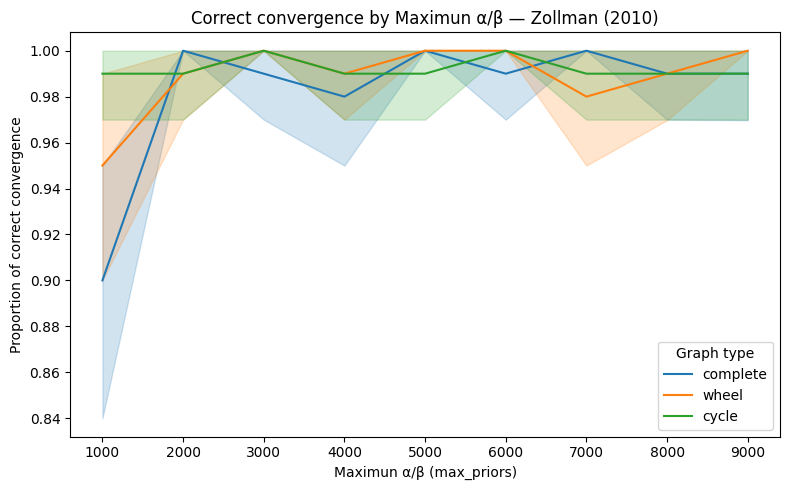

In [8]:
df_2 = pd.read_csv("results/Zollman_replication/2_different_priors.csv")
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_2, x="max_priors", y="Correct Convergence",
             hue="graph", ax=ax)
ax.set_title("Correct convergence by Maximun α/β — Zollman (2010)")
ax.set_xlabel("Maximun α/β (max_priors)")
ax.set_ylabel("Proportion of correct convergence")
ax.legend(title="Graph type")
plt.tight_layout()
plt.savefig("results/Zollman_replication/2_different_priors")
plt.show()

**Results**

The effect found by Zollman does not obtain, as with higher priors we find higher convergence rates for more conncected kind of graphs, but no reduction in less connected ones.

## Investigation of discrepancies in Analysis 2

### Hypothesis 1
Zollman does not specify that the number of pull per step is identical to the one chosen in the previous experiment. Even though it seemed reasonable to assume that no other changes were made, halving the pulls may lead to the described result. In fact, limiting the number of pulls can lead to less efficient convergence for less connected graphs, which may not be able to overcome prior beliefs with limited amount of evidence within the 10000 steps. We test this hypothesis in the following simulation, with now 500 pulls per step.

### Model parameters

| Parameter | This model | Original paper | Notes |
|---|---|---|---|
| n | 7 | 7 | identical |
| a_objective | 0.5 | 0.5 | identical |
| b_objective | 0.499 | 0.499 | identical |
| max_priors | 1000-10000 | 1000-10000 | identical |
| step_pulls | 500 | ? | we halved the number of pulls to try to obtain the effect |
| graph | complete, wheel, cycle | complete, wheel, cycle | identical |
| iterations | 1000 | 10000 | sufficient for statistical purposes |
| max_steps | 5000 | 10000 | identical |

**Deviations from original:** Number of iterations for the same parameters and, notably, **pulls per step**.

In [3]:
parameters_2_b = {
    "n": 7,
    "a_objective": 0.5,
    "b_objective": 0.499,
    "max_priors": range(1000, 11000, 1000),
    "graph": ["complete", "wheel", "cycle"],
    "theory_threshold": 0,
    "step_pulls": 500,
    "dynamic": None,
    "criticism": False,
    "inertia": 0,
    "seed": None
}

results_2_b = mesa.batch_run(
    Bandit,
    parameters=parameters_2_b,
    iterations=1000,
    max_steps=10000
)

df_2_b = pd.DataFrame(results_2_b)
Path("results/Zollman_replication/").mkdir(parents=True, exist_ok=True)
df_2_b.to_csv("results/Zollman_replication/2_b_different_priors.csv")

  0%|          | 0/30000 [00:00<?, ?it/s]

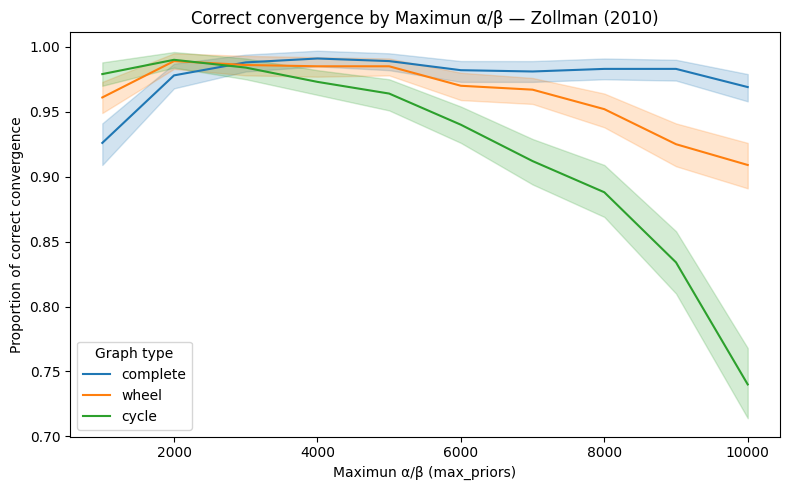

In [4]:
df_2_b = pd.read_csv("results/Zollman_replication/2_b_different_priors.csv")
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_2_b, x="max_priors", y="Correct Convergence",
             hue="graph", ax=ax)
ax.set_title("Correct convergence by Maximun α/β — Zollman (2010)")
ax.set_xlabel("Maximun α/β (max_priors)")
ax.set_ylabel("Proportion of correct convergence")
ax.legend(title="Graph type")
plt.tight_layout()
plt.savefig("results/Zollman_replication/2_b_different_priors")
plt.show()

**Results of investigation**

Now we match the results obtained by Zollman almost perfectly. 

## Discrepancies

| Analysis | Claim | Expected | Obtained | Likely cause |
|---|---|---|---|---|
| 2 | Complete and wheel graphs lose over complete at high max priors values | about 70% correct convergence for the cycle at max_priors = 10000 | almost 100% | The results were obtained halving the number of pulls per step

## Conclusions

The replication successfully reproduce Zollman's (2010) main finding that sparser networks outperform denser ones in terms of correct convergence frequency. However, we weren't able to replicate his second finding about the inversion of this tendency with higher maxium priors. The effect was only obtained halving the number of pulls per step specified by Zollman for the first analysis.